# Quick synthetic to verify that the code works as intended

In [1]:
import pygmt
import numpy as np
import bordado as bd
import boule as bl
import harmonica as hm
import verde as vd

import spherical as sph

## Forward modeling

Test the forward modeling functions and see if they make sense.

In [2]:
region = (-60, -30, -40, -10)
grid_coordinates = bd.grid_coordinates(region, spacing=10 / 60, non_dimensional_coords=100e3)
dipole = (-45, -25, -100e3)
# Regional field
inclination, declination = -30, 0
dipole_moment = hm.magnetic_angles_to_vec(1e12, inclination, declination)
magnetic_field = sph.dipole_magnetic_geodetic(grid_coordinates, dipole, dipole_moment)
total_field_anomaly = vd.make_xarray_grid(
    grid_coordinates,
    hm.total_field_anomaly(magnetic_field, inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid
total_field_anomaly

<xarray.DataArray 'grid' (latitude: 181, longitude: 181)> Size: 262kB
array([[ 4.86143574e-06,  5.02195955e-06,  5.18642247e-06, ...,
         5.18642247e-06,  5.02195955e-06,  4.86143574e-06],
       [ 4.79483801e-06,  4.95749678e-06,  5.12425142e-06, ...,
         5.12425142e-06,  4.95749678e-06,  4.79483801e-06],
       [ 4.72219558e-06,  4.88690934e-06,  5.05587918e-06, ...,
         5.05587918e-06,  4.88690934e-06,  4.72219558e-06],
       ...,
       [-1.81216725e-06, -1.70270658e-06, -1.58776295e-06, ...,
        -1.58776295e-06, -1.70270658e-06, -1.81216725e-06],
       [-1.71910298e-06, -1.61049160e-06, -1.49655789e-06, ...,
        -1.49655789e-06, -1.61049160e-06, -1.71910298e-06],
       [-1.63022545e-06, -1.52253928e-06, -1.40968875e-06, ...,
        -1.40968875e-06, -1.52253928e-06, -1.63022545e-06]],
      shape=(181, 181))
Coordinates:
  * longitude  (longitude) float64 1kB -60.0 -59.83 -59.67 ... -30.17 -30.0
  * latitude   (latitude) float64 1kB -40.0 -39.83 -39.67 ... -10.17 -10.0
    height     (latitude, longitude) float64 262kB 1e+05 1e+05 ... 1e+05 1e+05

Make a map with PyGMT so we can visually inspect the anomaly. It should have a positive part to the North and negative to the South.

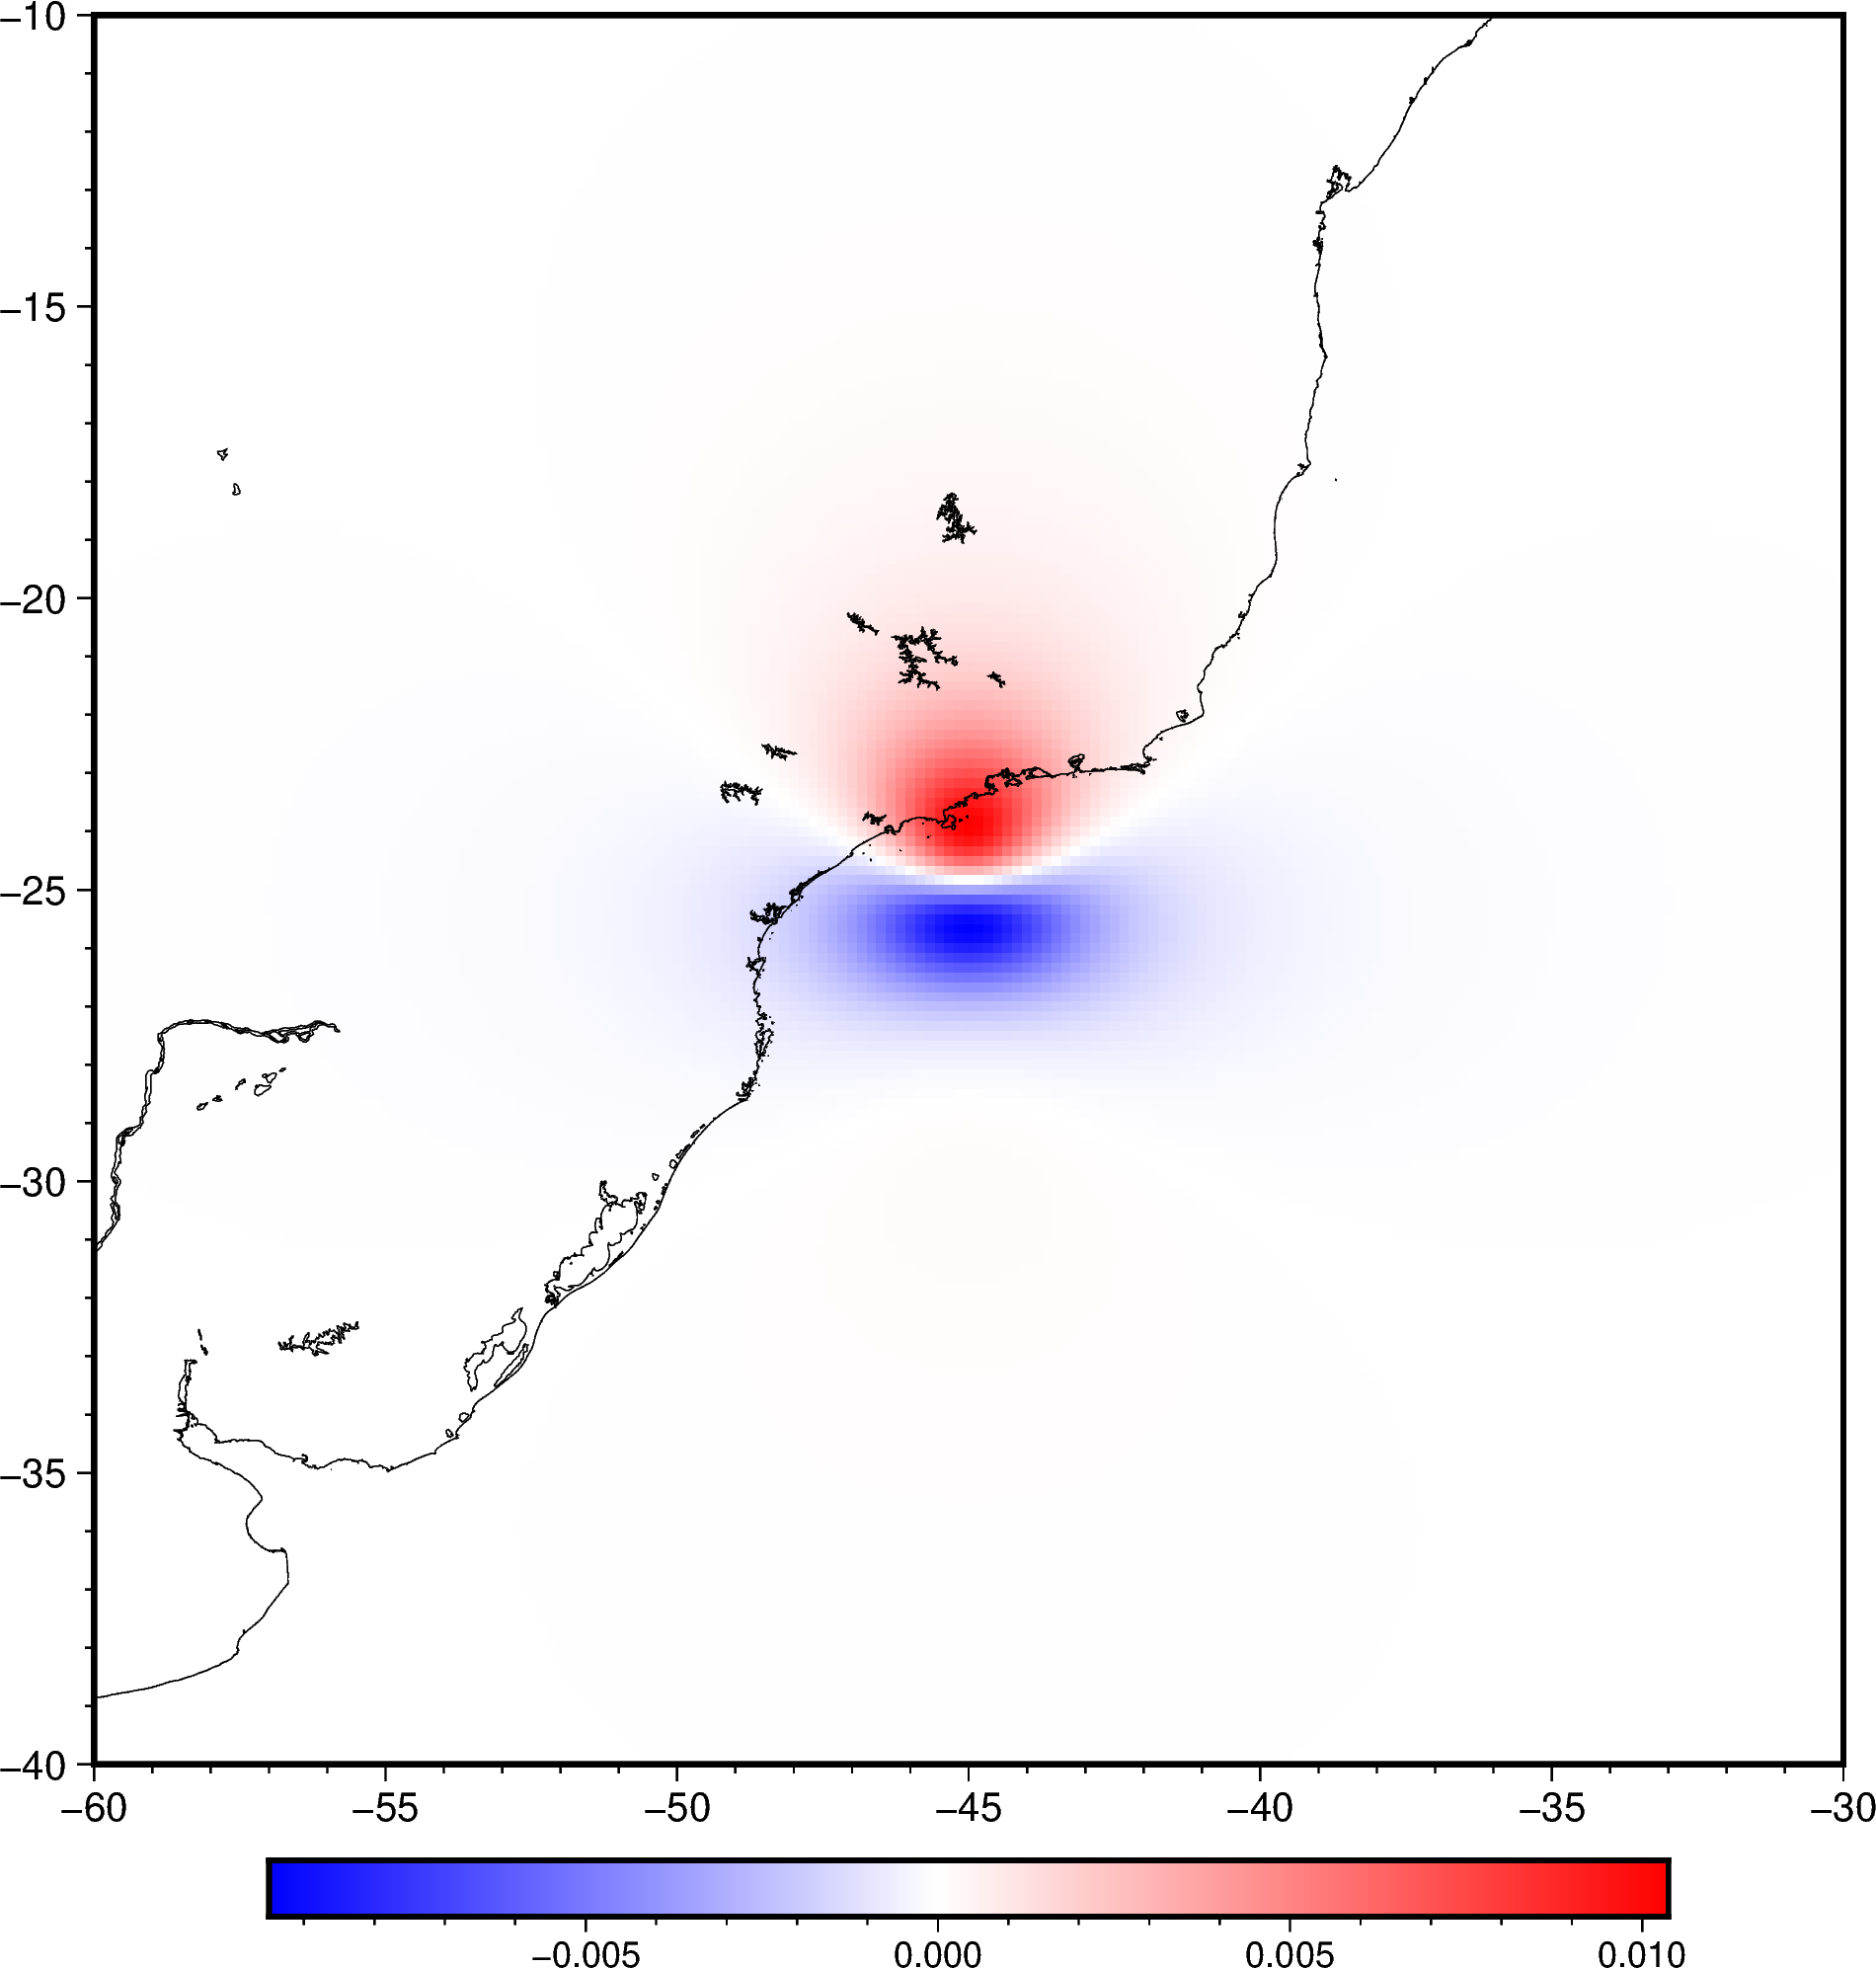

In [3]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

## Simple equivalent source inversion

Try recovering the dipole field with a simple single layer inversion.

In [4]:
coordinates = bd.random_coordinates(region, 1000, non_dimensional_coords=100e3)
magnetic_field_obs = sph.dipole_magnetic_geodetic(coordinates, dipole, dipole_moment)
data = hm.total_field_anomaly(magnetic_field_obs, inclination, declination)

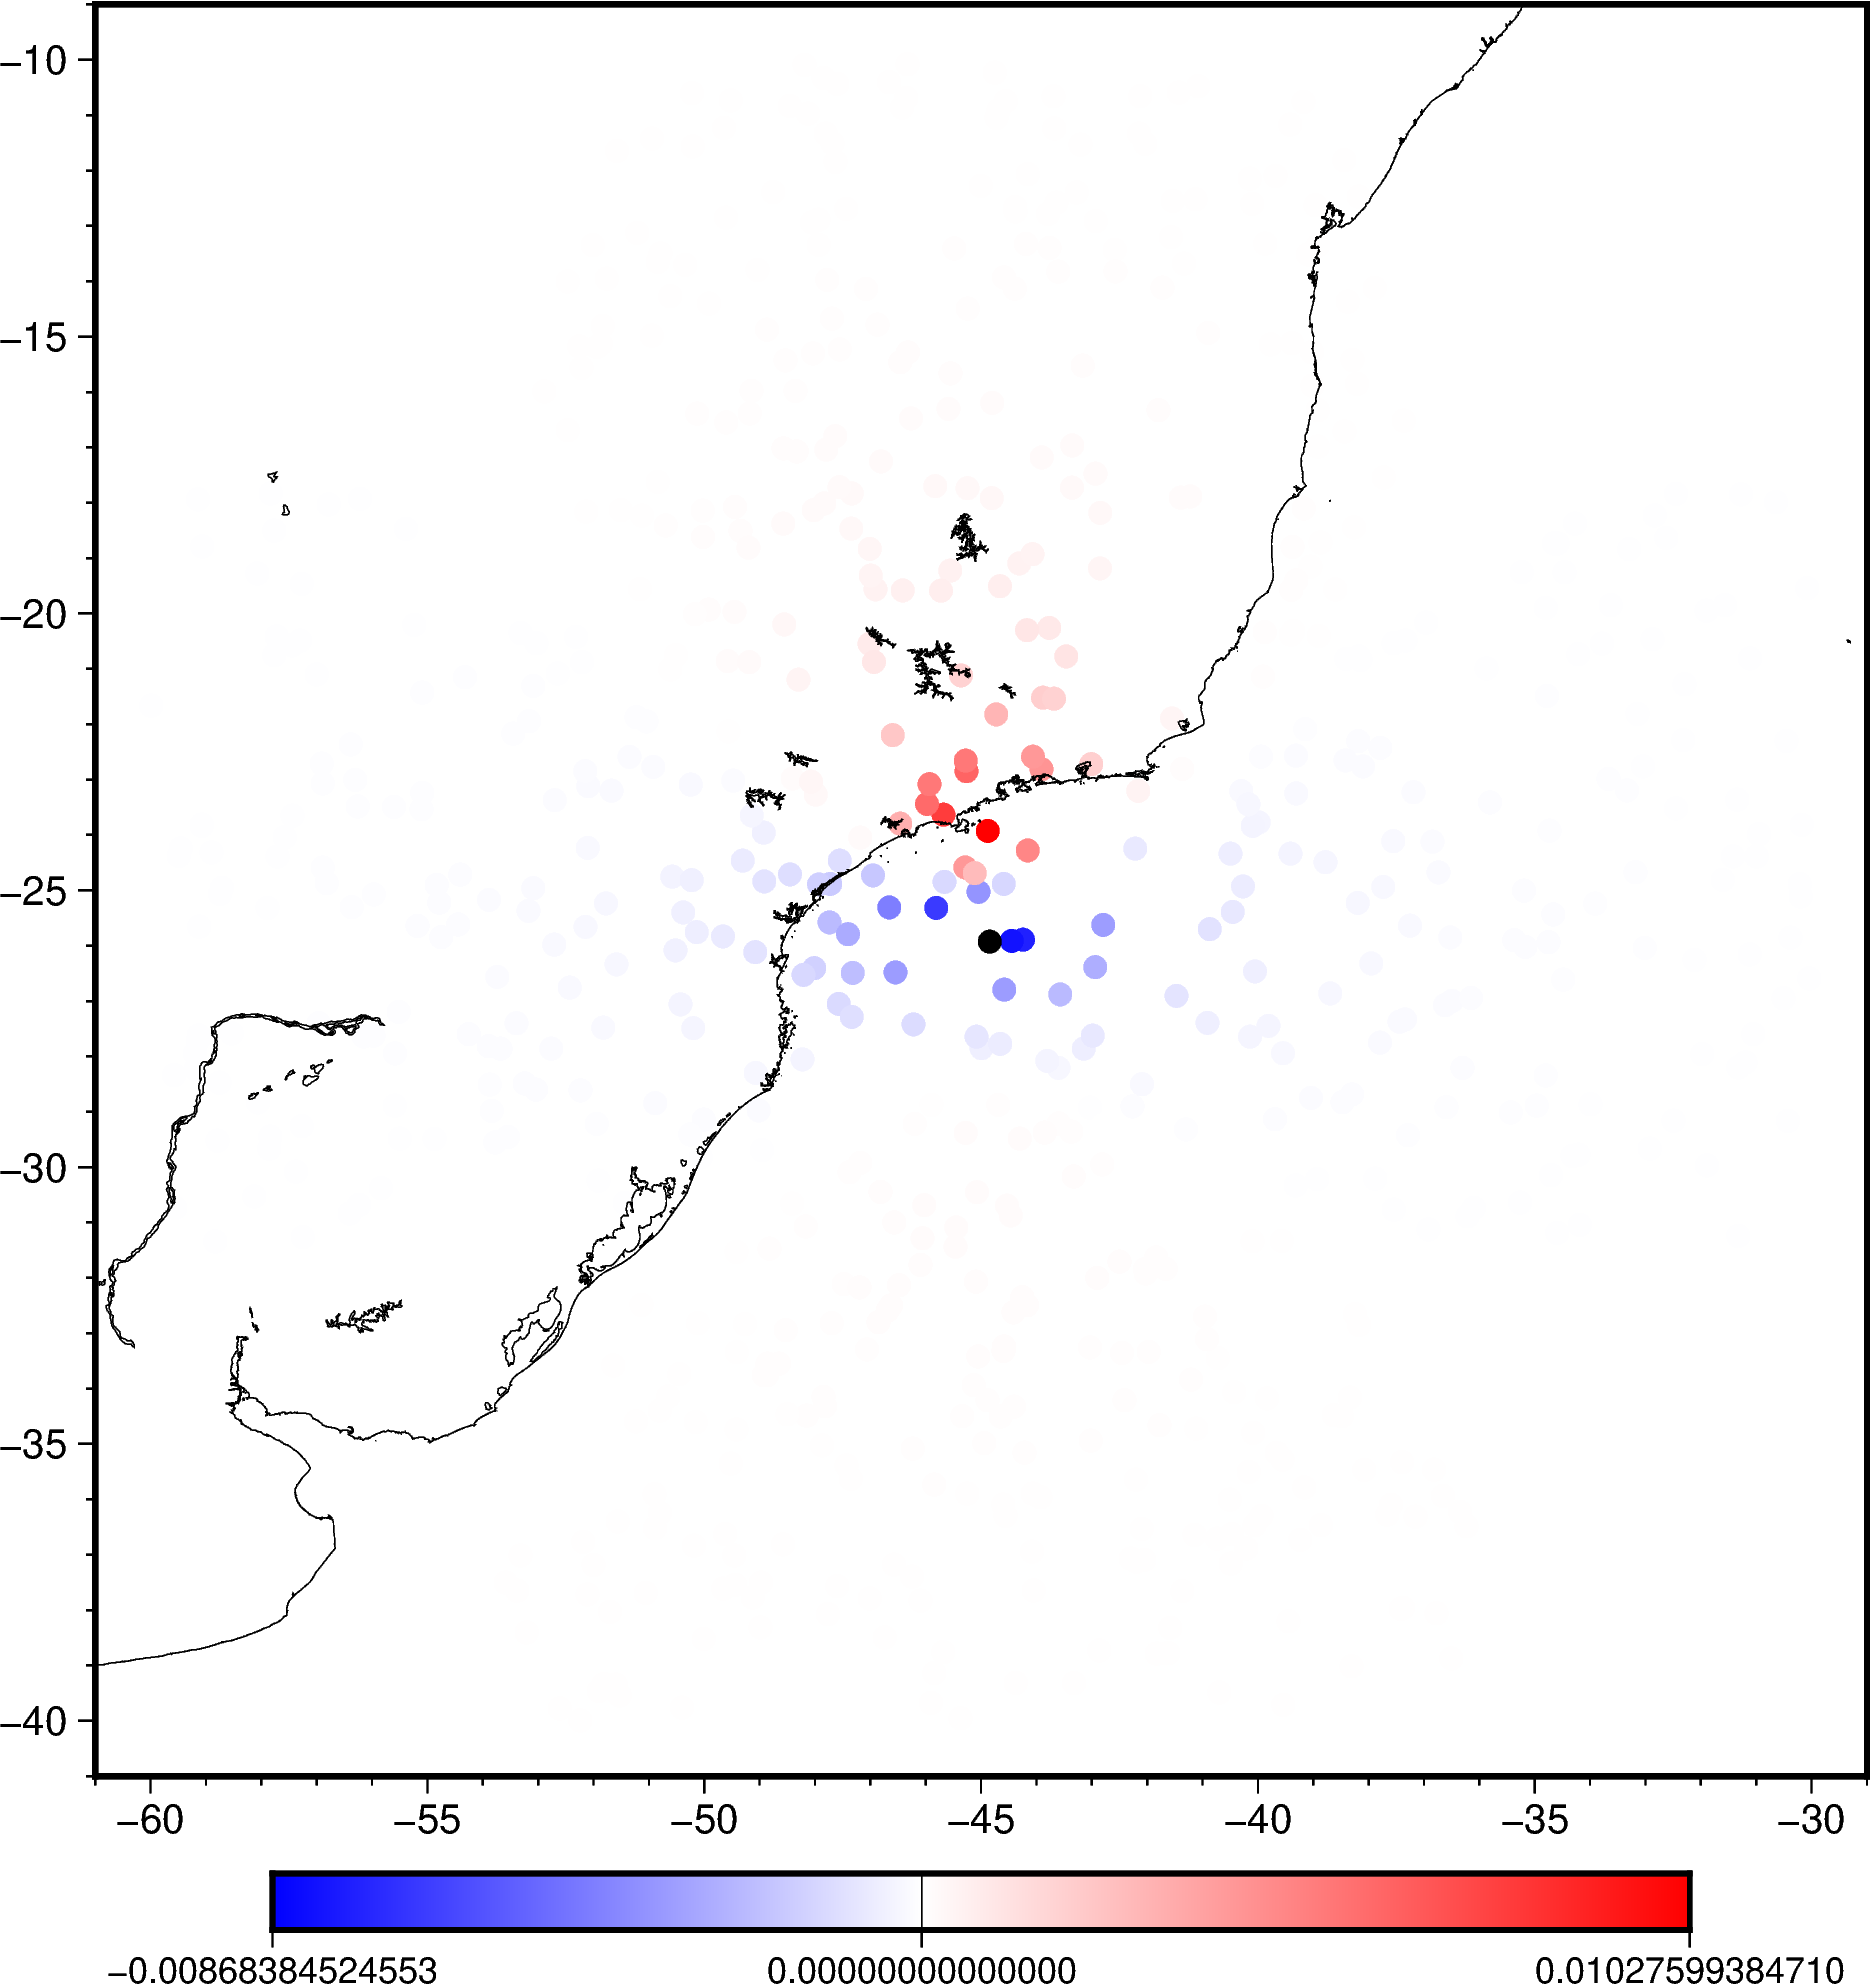

In [5]:
fig = pygmt.Figure()
pygmt.makecpt(cmap="polar+h", series=[data.min(), data.max()])
fig.plot(x=coordinates[0], y=coordinates[1], fill=data, style="c0.2c", cmap=True, frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()

In [6]:
%%time
eqs = sph.EquivalentSourcesMagGeod(damping=1e-8, depth=200e3)
eqs.fit(coordinates, inclination, declination, data)

CPU times: user 954 ms, sys: 25.7 ms, total: 980 ms
Wall time: 558 ms


In [7]:
total_field_anomaly_predicted = vd.make_xarray_grid(
    grid_coordinates,
    hm.total_field_anomaly(eqs.predict(grid_coordinates), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

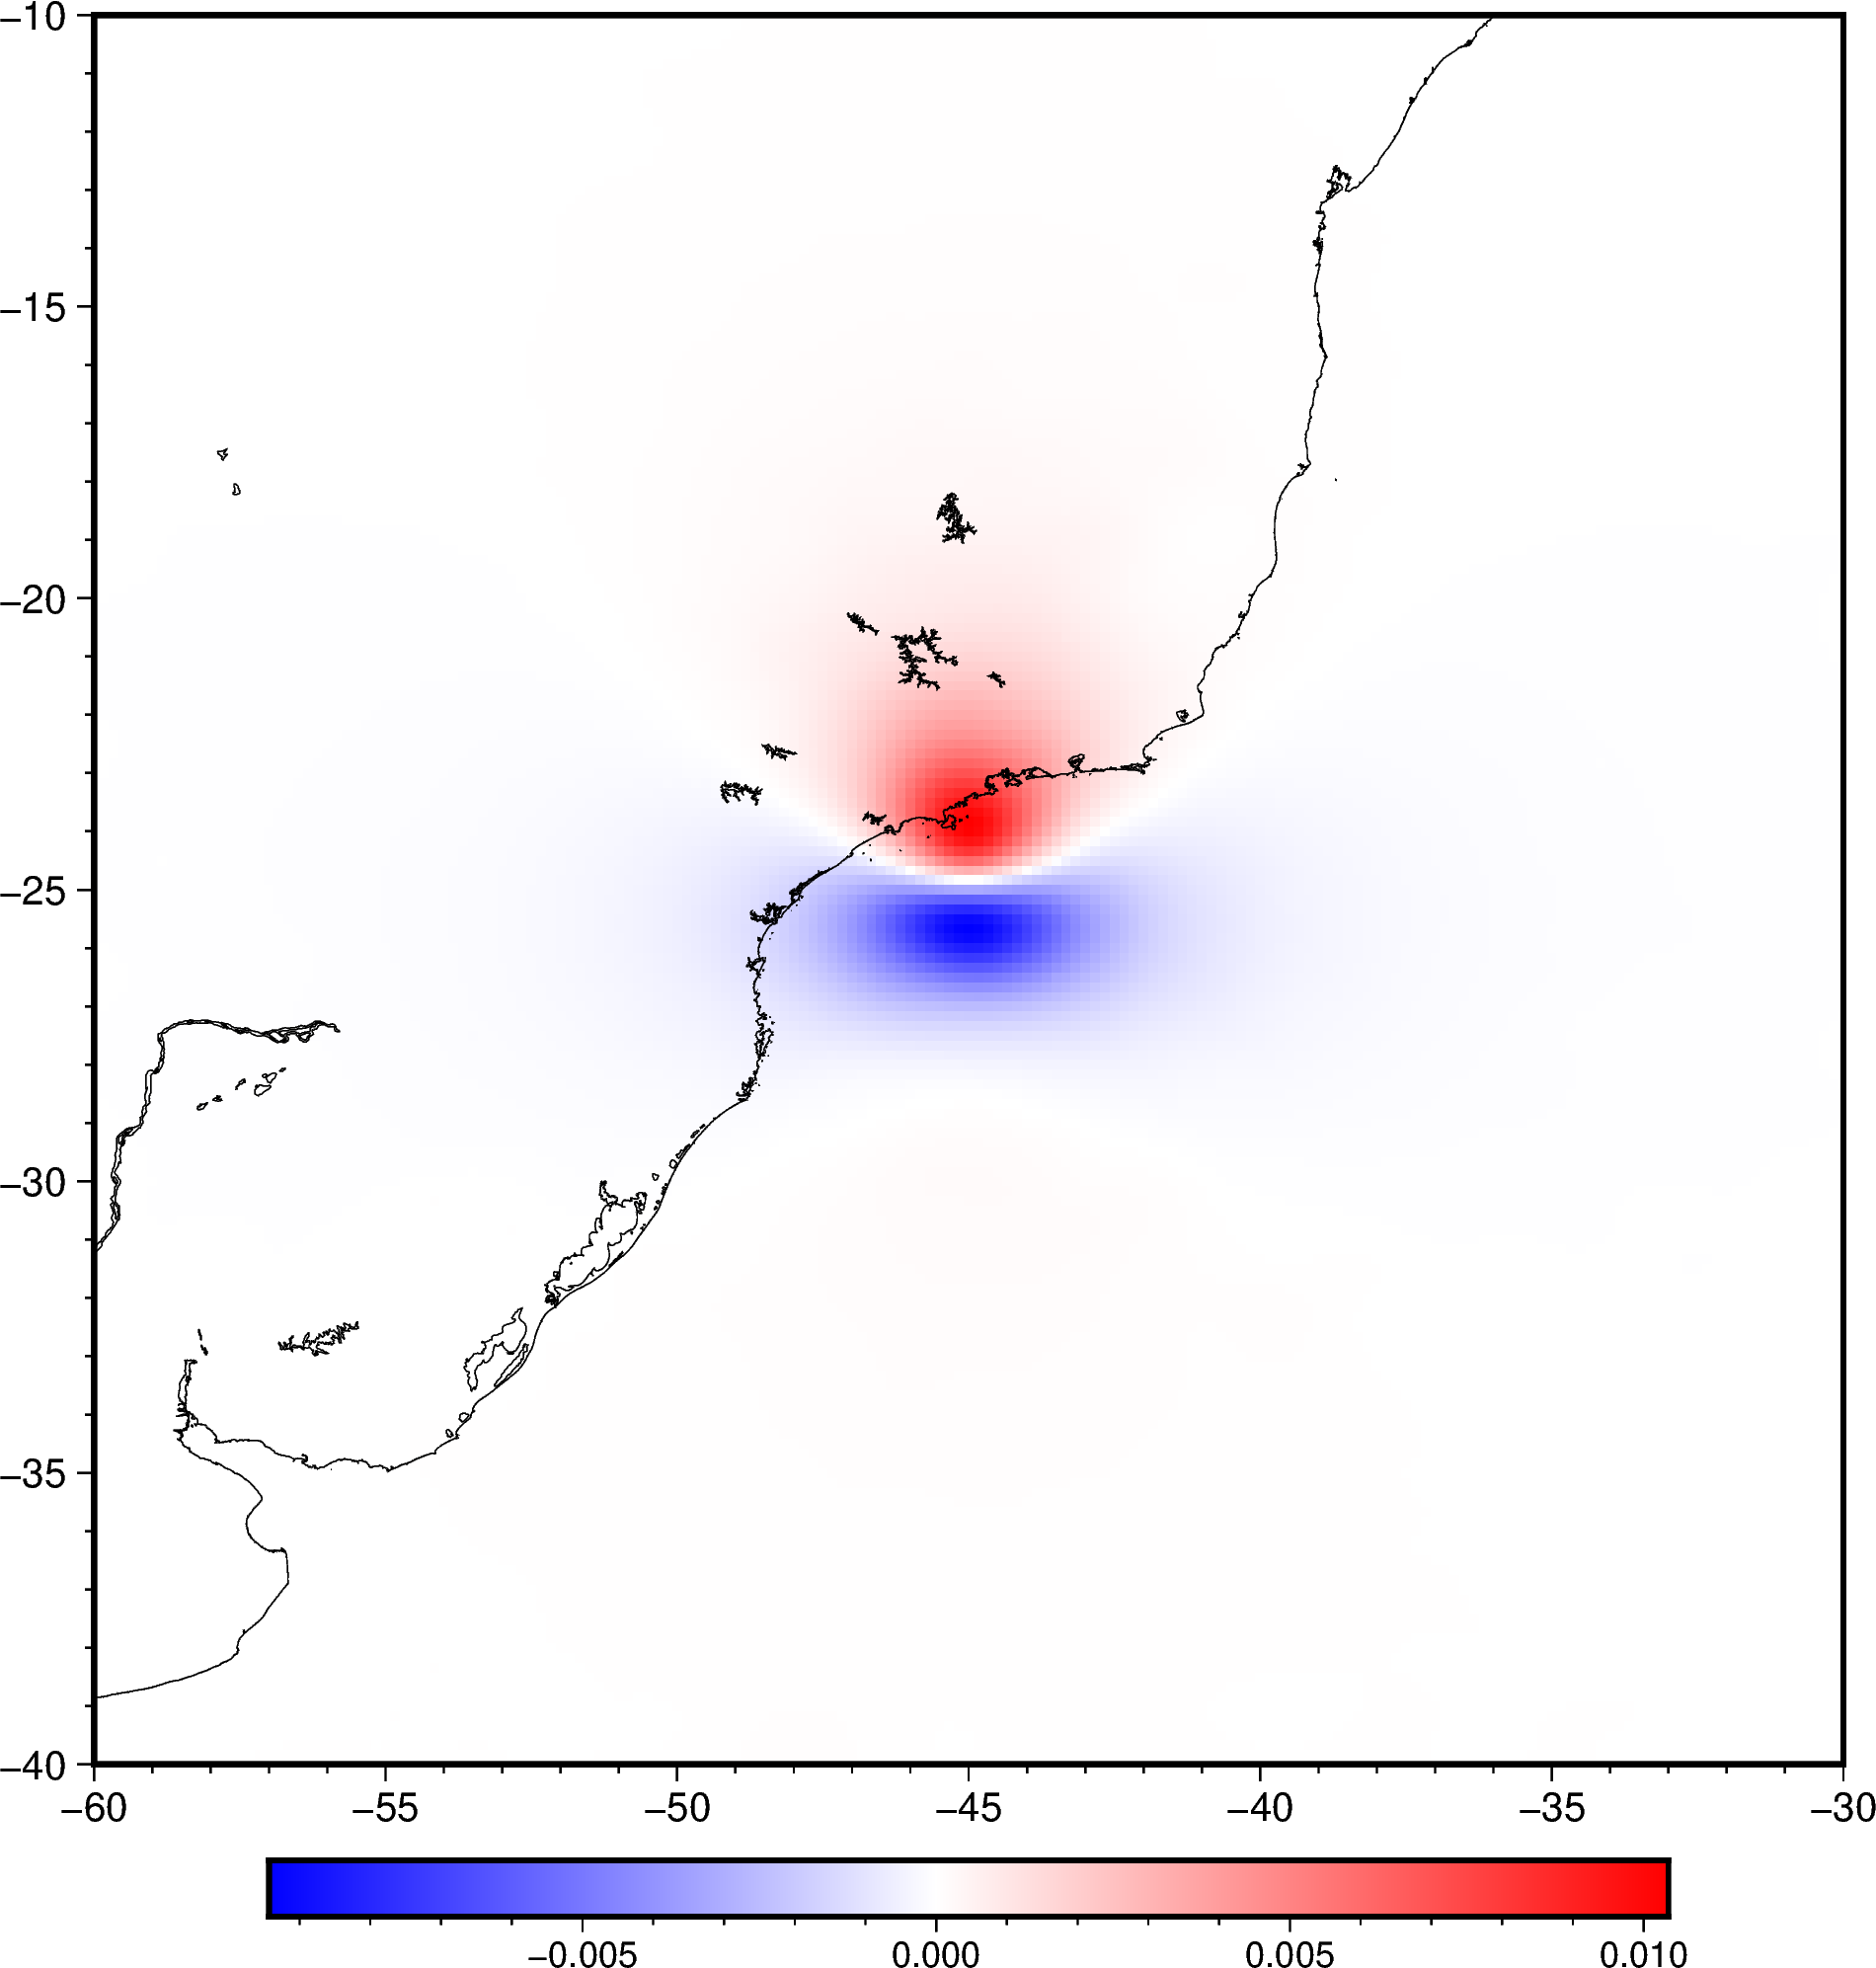

In [8]:
fig = pygmt.Figure()
fig.grdimage(total_field_anomaly_predicted, cmap="polar+h", frame=True)
fig.colorbar()
fig.coast(shorelines=True)
fig.show()